<a href="https://colab.research.google.com/github/rotoncsedu/Computer-Vision/blob/main/Emotion_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
! pip install -q kaggle

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mdalimranroton","key":"77970a92a73d89c8164499b9d653fd8b"}'}

In [5]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/

In [6]:
!chmod 600 /root/.kaggle/kaggle.json

In [8]:
!kaggle datasets download -d muhammadhananasghar/human-emotions-datasethes --unzip

Dataset URL: https://www.kaggle.com/datasets/muhammadhananasghar/human-emotions-datasethes
License(s): unknown
100% 309M/309M [00:05<00:00, 64.5MB/s]



In [50]:
train_dir = "/content/Emotions Dataset/Emotions Dataset/train"
val_dir = "/content/Emotions Dataset/Emotions Dataset/test"
CLASS_NAME = ["angry", "happy", "sad"]
CONFIGURATION ={
    "BATCH_SIZE" : 32,
    "IMAGE_SIZE" : 256,
    "CHANNELS" : 3,
    "H_EPOCHS" : 20,
    "LEARNING_RATE" : 0.0001,
    "DROPOUT_RATE" : 0.2,
    "REGULARIZATION_RATE" : 0.001,
    "N_FILTER" : 6,
    "KERNEL_SIZE" : 3,
    "POOL_SIZE" : 2,
    "N_STRIDES" : 1,
    "N_PADDING" : "same",
    "N_DENSE_1" : 100,
    "N_DENSE_2" : 10,
    "N_OUTPUT" : 3,
}

In [34]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    class_names=CLASS_NAME,
    batch_size=CONFIGURATION["BATCH_SIZE"],
    image_size=(CONFIGURATION["IMAGE_SIZE"],CONFIGURATION["IMAGE_SIZE"]),
    shuffle=True,
    seed=99,
)

Found 6799 files belonging to 3 classes.


In [35]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    class_names=CLASS_NAME,
    batch_size=CONFIGURATION["BATCH_SIZE"],
    image_size=(CONFIGURATION["IMAGE_SIZE"],CONFIGURATION["IMAGE_SIZE"]),
    shuffle=True,
    seed=99,
)

Found 2278 files belonging to 3 classes.


In [23]:
for i in train_dataset.take(1):
  print(i[1])

tf.Tensor(
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]], shape=(32, 3), dtype=float32)


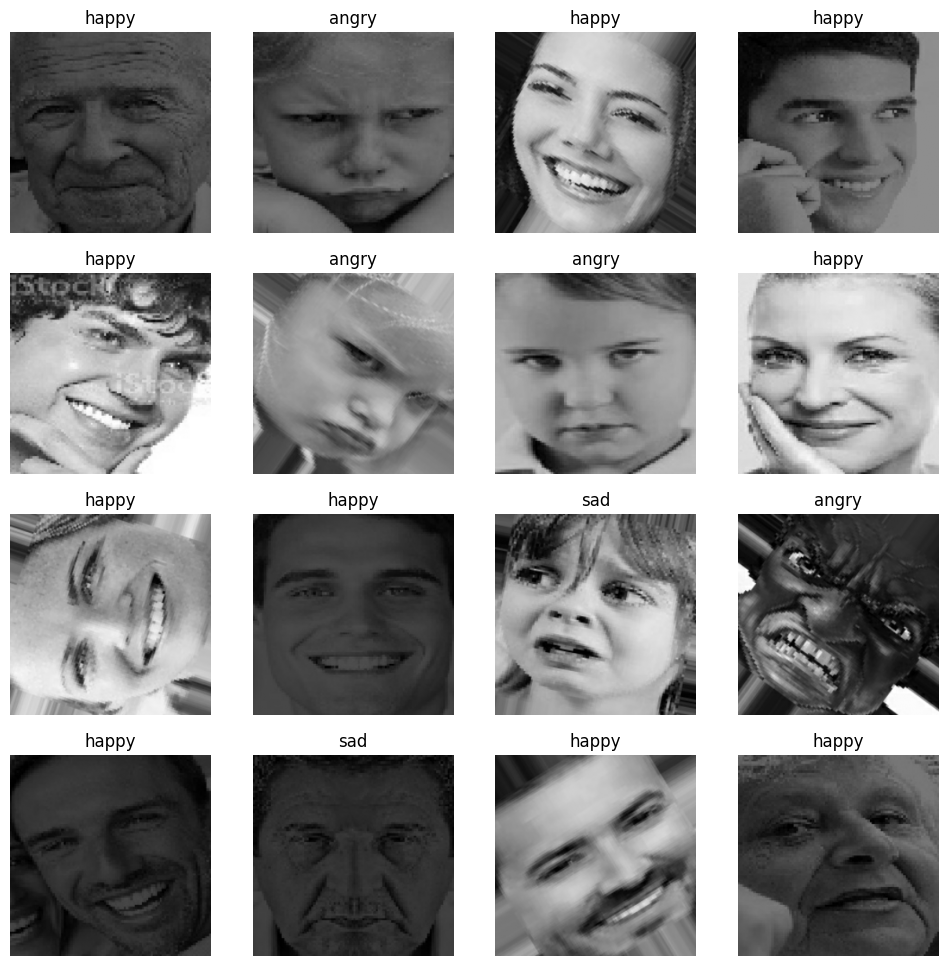

In [25]:
plt.figure(figsize=(12, 12))
for images, labels in train_dataset.take(1):
  for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8")/255)
    plt.title(CLASS_NAME[np.argmax(labels[i])])
    plt.axis("off")

In [26]:
traning_dataset = (
    train_dataset
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)
val_dataset = (
    val_dataset
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

In [29]:
for i in train_dataset.take(1):
  print(i)

(<tf.Tensor: shape=(32, 256, 256, 3), dtype=float32, numpy=
array([[[[114.       , 114.       , 114.       ],
         [114.       , 114.       , 114.       ],
         [114.       , 114.       , 114.       ],
         ...,
         [111.6875   , 111.6875   , 111.6875   ],
         [111.1875   , 111.1875   , 111.1875   ],
         [112.       , 112.       , 112.       ]],

        [[116.4375   , 116.4375   , 116.4375   ],
         [115.11719  , 115.11719  , 115.11719  ],
         [114.25391  , 114.25391  , 114.25391  ],
         ...,
         [111.6875   , 111.6875   , 111.6875   ],
         [111.1875   , 111.1875   , 111.1875   ],
         [112.       , 112.       , 112.       ]],

        [[121.125    , 121.125    , 121.125    ],
         [120.05859  , 120.05859  , 120.05859  ],
         [118.17969  , 118.17969  , 118.17969  ],
         ...,
         [111.21484  , 111.21484  , 111.21484  ],
         [111.1875   , 111.1875   , 111.1875   ],
         [112.       , 112.       , 112.    

In [62]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import L2
#regularization_rate = 0.001
#dropout_rate = 0.2
inputs = keras.Input(shape = (CONFIGURATION["IMAGE_SIZE"],CONFIGURATION["IMAGE_SIZE"],CONFIGURATION["CHANNELS"]), dtype=tf.float32)
x= layers.Rescaling(1./255)(inputs)
x= layers.Conv2D(filters=CONFIGURATION["N_FILTER"], kernel_size=CONFIGURATION["KERNEL_SIZE"], activation="relu", kernel_regularizer= L2(CONFIGURATION["REGULARIZATION_RATE"]))(x)
x = layers.BatchNormalization()(x)
x= layers.MaxPooling2D(pool_size=CONFIGURATION["POOL_SIZE"])(x)
x= layers.Dropout(CONFIGURATION["DROPOUT_RATE"])(x)
x= layers.Conv2D(filters=CONFIGURATION["N_FILTER"], kernel_size=CONFIGURATION["KERNEL_SIZE"], activation="relu",kernel_regularizer=L2(CONFIGURATION["REGULARIZATION_RATE"]))(x)
x = layers.BatchNormalization()(x)
x= layers.MaxPooling2D(pool_size=CONFIGURATION["POOL_SIZE"])(x)
x= layers.Dropout(CONFIGURATION["DROPOUT_RATE"])(x)
x= layers.Conv2D(filters=CONFIGURATION["N_FILTER"], kernel_size=CONFIGURATION["KERNEL_SIZE"], activation="relu",kernel_regularizer=L2(CONFIGURATION["REGULARIZATION_RATE"]))(x)
x = layers.BatchNormalization()(x)
x= layers.MaxPooling2D(pool_size=CONFIGURATION["POOL_SIZE"])(x)
x= layers.Dropout(CONFIGURATION["DROPOUT_RATE"])(x)
x= layers.Conv2D(filters=CONFIGURATION["N_FILTER"], kernel_size=CONFIGURATION["KERNEL_SIZE"], activation="relu",kernel_regularizer=L2(CONFIGURATION["REGULARIZATION_RATE"]))(x)
x = layers.BatchNormalization()(x)
x= layers.MaxPooling2D(pool_size=CONFIGURATION["POOL_SIZE"])(x)
x= layers.Dropout(CONFIGURATION["DROPOUT_RATE"])(x)
x= layers.Conv2D(filters=CONFIGURATION["N_FILTER"], kernel_size=CONFIGURATION["KERNEL_SIZE"], activation="relu",kernel_regularizer=L2(CONFIGURATION["REGULARIZATION_RATE"]))(x)
x = layers.BatchNormalization()(x)
x= layers.MaxPooling2D(pool_size=CONFIGURATION["POOL_SIZE"])(x)

x= layers.Flatten()(x)

x= layers.Dense(CONFIGURATION["N_DENSE_1"], activation="relu",kernel_regularizer=L2(CONFIGURATION["REGULARIZATION_RATE"]))(x)
#BatchNormalization(),
x= layers.Dropout(CONFIGURATION["DROPOUT_RATE"])(x)
x= layers.Dense(CONFIGURATION["N_DENSE_2"], activation="relu",kernel_regularizer=L2(CONFIGURATION["REGULARIZATION_RATE"]))(x)
#BatchNormalization(),

outputs= layers.Dense(CONFIGURATION["N_OUTPUT"], activation="softmax")(x)
model= keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 254, 254, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 254, 254, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 127, 127, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 127, 127, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 125, 125, 6)    │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 125, 125, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 62, 62, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 62, 62, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 60, 60, 6)      │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 60, 60, 6)      │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 30, 30, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 30, 30, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 28, 28, 6)      │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 6)      │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 12, 12, 6)      │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 12, 12, 6)      │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 6, 6, 6)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 216)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 24,351 (95.12 KB)

 Trainable params: 24,291 (94.89 KB)

 Non-trainable params: 60 (240.00 B)

In [63]:
loss_function = keras.losses.CategoricalCrossentropy()


In [64]:
from tensorflow.keras.metrics import CategoricalAccuracy, Precision, Recall, TopKCategoricalAccuracy
metrics = [CategoricalAccuracy(name = "accuracy"), Precision(name = "precision"), Recall(name = "recall"), TopKCategoricalAccuracy(k=2, name = "top_2_accuracy")]

In [65]:
optimizer = keras.optimizers.Adam(learning_rate=CONFIGURATION["LEARNING_RATE"])
model.compile(optimizer=optimizer, loss=loss_function, metrics = metrics)

In [66]:
history = model.fit(
    traning_dataset,
    epochs=CONFIGURATION["H_EPOCHS"],
    batch_size=CONFIGURATION["BATCH_SIZE"],
    verbose=1,
    validation_data=val_dataset,
)

Epoch 1/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - accuracy: 0.4721 - loss: 1.2002 - precision: 0.6125 - recall: 0.2074 - top_2_accuracy: 0.7758 - val_accuracy: 0.4421 - val_loss: 1.2277 - val_precision: 0.5714 - val_recall: 0.0053 - val_top_2_accuracy: 0.7709
Epoch 2/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.5708 - loss: 1.0590 - precision: 0.6813 - recall: 0.3871 - top_2_accuracy: 0.8239 - val_accuracy: 0.4438 - val_loss: 1.3498 - val_precision: 0.4455 - val_recall: 0.4416 - val_top_2_accuracy: 0.7739
Epoch 3/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.6192 - loss: 0.9832 - precision: 0.7141 - recall: 0.4574 - top_2_accuracy: 0.8504 - val_accuracy: 0.5193 - val_loss: 1.1044 - val_precision: 0.5552 - val_recall: 0.4438 - val_top_2_accuracy: 0.8227
Epoch 4/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.6445 - loss: 0.9247 - precision: 0.7281 - recall: 0.5110 - top_2_accuracy: 0.8666 - val_accuracy: 0.5439 - val_loss: 1.0836 - val_precisi

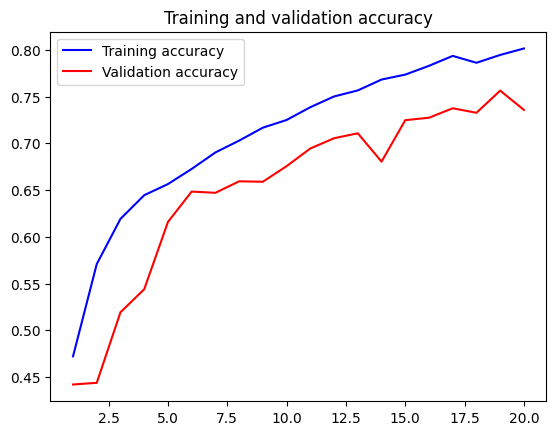

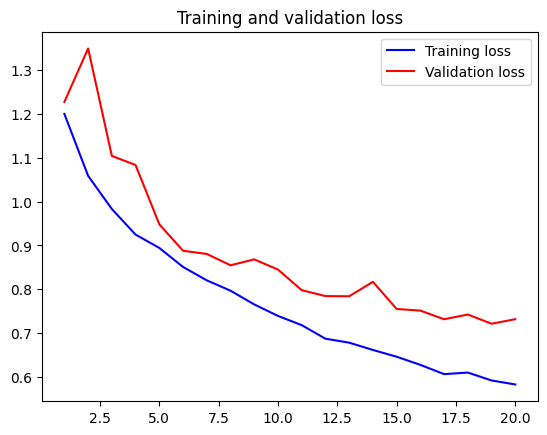

In [67]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy)+1)
plt.plot(epochs, accuracy, "b", label="Training accuracy")
plt.plot(epochs, val_accuracy, "r", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "b", label="Training loss")
plt.plot(epochs, val_loss, "r", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()